### Search Engine With Tools Agents


In [1]:
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun

from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper

/var/folders/c0/yng66gs97096k9bm6d0d36hh0000gn/T/ipykernel_72470/3139576355.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun


In [2]:
import wikipedia
from datetime import timedelta

# Wikipedia now requires a proper User-Agent, else it returns HTTP 403 (which the
# old wikipedia package can't parse -> JSONDecodeError). Also rate-limit to be polite
# and avoid intermittent blocks when the agent makes repeated calls.
wikipedia.set_user_agent("genai-learning-app/1.0 (kskbasha777@gmail.com)")
wikipedia.set_rate_limiting(True, min_wait=timedelta(milliseconds=200))

api_wrapper_wiki = WikipediaAPIWrapper(top_k_results=1, doc_content_chars_max=250)


wiki = WikipediaQueryRun(api_wrapper=api_wrapper_wiki)

wiki.name

'wikipedia'

In [3]:
arxiv_wrapper = ArxivAPIWrapper(top_k_results=1, doc_content_chars_max=250)

arxiv = ArxivQueryRun(api_wrapper=arxiv_wrapper)

arxiv.name

'arxiv'

In [4]:
tools =[wiki, arxiv]

### Custom tool @Wikipedida

In [5]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.tools.retriever import create_retriever_tool

# 1. Load
loader = WebBaseLoader("https://docs.langchain.com/oss/python/langchain/tools")
docs = loader.load()

# 2. Split
documents = RecursiveCharacterTextSplitter(
    chunk_size=1000, chunk_overlap=200
).split_documents(docs)

# 3. Embed + store in a vector DB
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
vectordb = FAISS.from_documents(documents, embeddings)

# 4. Retriever
retriever = vectordb.as_retriever()

# 5. Wrap the retriever as a custom tool (runtime tool registration)
retriever_tool = create_retriever_tool(
    retriever,
    name="langchain_docs_search",
    description="Search the LangChain tools documentation. Use this for any "
    "questions about LangChain tools, custom tools, or tool registration.",
)

# Register the custom RAG retriever tool alongside the others
tools = [wiki, arxiv, retriever_tool]

retriever_tool.name

/Users/bashaksk/Pictures/genai-projects/langchainupdated/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
USER_AGENT environment variable not set, consider setting it to identify your requests.
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7390.02it/s]


'langchain_docs_search'

In [6]:
### Run al the docs With Agents and LLms

## Tools , LLMs - Agent Executors

import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq

load_dotenv()

os.environ['LANGCHAIN_API_KEY'] = os.getenv("LANGCHAIN_API_KEY")

os.environ['LANGCHAIN_TRACING_V2'] = "true"

os.environ['LANGCHAIN_PROJECT'] = os.getenv("LANGCHAIN_PROJECT")

os.environ['GROQ_API_KEY'] = os.getenv('GROQ_API_KEY')

grok_api_key = os.getenv('GROQ_API_KEY')

# NOTE: llama-3.3-70b-versatile has a known Groq bug where it emits tool calls
# in Llama's native <function=...> syntax, which Groq rejects (tool_use_failed).
# openai/gpt-oss models are built for agentic/tool use and format tool calls correctly.
llm = ChatGroq(model='openai/gpt-oss-20b', temperature=0)

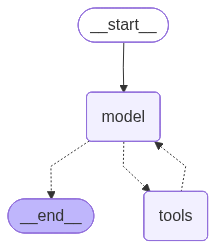

In [7]:
## Agents
from langchain.agents import create_agent

# In v1, create_agent takes a plain system prompt string.
# No ChatPromptTemplate / hub.pull / agent_scratchpad needed — it's all managed internally.
system_prompt = (
    "You are a helpful research assistant. "
    "Use the available tools (Wikipedia, Arxiv, and the LangChain docs search) "
    "to answer the user's questions accurately."
)

agent = create_agent(
    model=llm,
    tools=tools,
    system_prompt=system_prompt,
)

agent

In [8]:
## Invoke the agent
response = agent.invoke(
    {"messages": [{"role": "user", "content": "What is LangChain? Tell me about machine learning too."}]}
)

# The full conversation is in response["messages"]; the final answer is the last message.
print(response["messages"][-1].content)

**LangChain**

LangChain is a **software framework** designed to make it easier to build applications that use large language models (LLMs) such as GPT‑4, Claude, or other transformer‑based models.  
Key points:

| Feature | What it does |
|---------|--------------|
| **LLM integration** | Provides a unified API for calling different LLM providers (OpenAI, Anthropic, Cohere, etc.) so developers don’t have to write provider‑specific code. |
| **Chainable components** | Lets you string together “tools” (e.g., web‑search, database queries, file‑reading) and LLM prompts in a modular way, forming a *chain* of operations that can be reused or composed. |
| **Prompt management** | Offers utilities for prompt templating, dynamic prompt generation, and prompt‑engineering best practices. |
| **Memory & state** | Supports short‑term and long‑term memory modules so a conversation or task can keep context across turns. |
| **Agent framework** | Enables building “agents” that can decide which tool t

In [9]:
## Invoke the agent
response = agent.invoke(
    {"messages": [{"role": "user", "content": "What is computer science?  please gimme a roadmap to understand how computer works and master it's science"}]}
)

# The full conversation is in response["messages"]; the final answer is the last message.
print(response["messages"][-1].content)

**What is Computer Science?**  
Computer science is the systematic study of *computation*, *information*, and *automation*. It blends theory, design, and implementation of algorithms and systems that process data, solve problems, and enable intelligent behavior. According to Wikipedia, the field spans:

- **Theoretical foundations** – algorithms, complexity theory, computability, formal languages, and information theory.  
- **Systems and architecture** – operating systems, networking, distributed systems, and computer hardware.  
- **Software engineering** – programming languages, compilers, software design, and development practices.  
- **Applied domains** – artificial intelligence, machine learning, data science, graphics, human‑computer interaction, and more.

---

## Roadmap to Understand How a Computer Works & Master Computer Science

| Stage | Core Topics | Key Concepts | Suggested Resources |
|-------|-------------|--------------|---------------------|
| **1. Foundations** | •

In [10]:
## See which tool the agent selected

response = agent.invoke(
    {"messages": [{"role": "user",
                   "content": "Find the research paper 'Attention Is All You Need' on arxiv and summarize it."}]}
)

# tool_calls live on the AIMessages; collect the tool names the agent chose
for msg in response["messages"]:
    for tc in getattr(msg, "tool_calls", []):
        print("Selected tool:", tc["name"], "| args:", tc["args"])

print("\nFinal answer:\n", response["messages"][-1].content)

Selected tool: arxiv | args: {'query': 'Attention Is All You Need'}
Selected tool: arxiv | args: {'query': '"Attention Is All You Need" arXiv'}
Selected tool: arxiv | args: {'query': '1706.03762'}
Selected tool: arxiv | args: {'query': '1706.03762'}
Selected tool: arxiv | args: {'query': '1706.03762'}
Selected tool: arxiv | args: {'query': 'Attention Is All You Need arxiv 1706.03762'}

Final answer:
 I wasn’t able to retrieve the paper directly from the arXiv tool (it returned unrelated or withdrawn entries), so I’m summarizing it from the published record and the widely‑cited literature.

---

## “Attention Is All You Need”  
**Authors:** Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Łukasz Kaiser, Illia Polosukhin  
**arXiv ID:** 1706.03762  
**Published:** 2017 (NeurIPS 2017)  
**Link:** https://arxiv.org/abs/1706.03762

### Core Idea
Replace the recurrent and convolutional layers that dominate sequence‑to‑sequence models with a **pure‑atte